# HDBSCAN Clustering and Trend Detection

This notebook clusters content using HDBSCAN and detects trends on a biweekly basis.

## Imports and Setup

In [1]:
from qdrant_client import QdrantClient
from qdrant_client.models import Filter, FieldCondition, MatchValue
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
from typing import List, Dict, Optional
import os
from dotenv import load_dotenv
import openai
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns

# Clustering
import hdbscan
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

load_dotenv()

/Users/antoineestienne/GithubRepositories/ai-bootcamp-dev-repo/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/antoineestienne/GithubRepositories/ai-bootcamp-dev-repo/.venv/lib/python3.12/site-packages/hdbscan/robust_single_linkage_.py:175: SyntaxWarning: invalid escape sequence '\{'
  $max \{ core_k(a), core_k(b), 1/\alpha d(a,b) \}$.


True

In [2]:
CONTENT_COLLECTION_NAME = "Content-collection-00"

qdrant_url = os.getenv("QDRANT_URL")
qdrant_api_key = os.getenv("QDRANT_API_KEY")
qdrant_client = QdrantClient(
    url=qdrant_url,
    api_key=qdrant_api_key
)

## Helper Functions

In [13]:
def get_embedding(text, model="text-embedding-3-small"):
    """Get embedding for a single text."""
    response = openai.embeddings.create(
        input=[text],
        model=model,
    )
    return response.data[0].embedding


def get_embeddings_batch(text_list, model="text-embedding-3-small", batch_size=100):
    """Get embeddings for a batch of texts. Filters out invalid inputs."""
    # Filter out None, empty strings, and non-string values
    valid_texts = []
    valid_indices = []
    
    for idx, text in enumerate(text_list):
        if text is not None and isinstance(text, str) and text.strip():
            valid_texts.append(text.strip())
            valid_indices.append(idx)
    
    if not valid_texts:
        # Return None embeddings for all if no valid texts
        return [None] * len(text_list)
    
    # Get embeddings for valid texts
    all_embeddings = [None] * len(text_list)
    valid_embeddings = []
    
    if len(valid_texts) <= batch_size:
        response = openai.embeddings.create(input=valid_texts, model=model)
        valid_embeddings = [embedding.embedding for embedding in response.data]
    else:
        for i in range(0, len(valid_texts), batch_size):
            batch = valid_texts[i:i + batch_size]
            response = openai.embeddings.create(input=batch, model=model)
            valid_embeddings.extend([embedding.embedding for embedding in response.data])
            print(f"Processed {min(i + batch_size, len(valid_texts))} of {len(valid_texts)} valid texts")
    
    # Map embeddings back to original positions
    for idx, valid_idx in enumerate(valid_indices):
        all_embeddings[valid_idx] = valid_embeddings[idx]
    
    return all_embeddings

In [4]:
def retrieve_all_content_with_dates(qdrant_client, collection_name: str, limit: int = 10000):
    """
    Retrieve all content from Qdrant that has created_date and likes fields.
    Returns a list of points with their payloads.
    """
    # Scroll through all points
    all_points = []
    offset = None
    
    while True:
        result = qdrant_client.scroll(
            collection_name=collection_name,
            limit=limit,
            offset=offset,
            with_payload=True,
            with_vectors=False
        )
        
        points = result[0]
        if not points:
            break
            
        all_points.extend(points)
        offset = result[1]
        
        if offset is None:
            break
    
    # Filter points that have created_date (tweets)
    content_with_dates = []
    for point in all_points:
        payload = point.payload
        if payload.get("created_date") is not None:
            content_with_dates.append(point)
    
    return content_with_dates

In [5]:
def parse_datetime(date_str: str) -> Optional[datetime]:
    """Parse datetime string from various formats."""
    if date_str is None:
        return None
    
    if isinstance(date_str, datetime):
        return date_str
    
    # Try ISO format first
    try:
        return datetime.fromisoformat(date_str.replace('Z', '+00:00'))
    except (ValueError, AttributeError):
        pass
    
    # Try Twitter format: "Fri Nov 28 14:29:08 +0000 2025"
    try:
        return datetime.strptime(date_str, "%a %b %d %H:%M:%S %z %Y")
    except (ValueError, TypeError):
        pass
    
    return None

In [6]:
def create_biweekly_intervals(start_date: datetime, end_date: datetime) -> List[Dict[str, datetime]]:
    """
    Create biweekly (14-day) intervals between start and end dates.
    Returns a list of dicts with 'start' and 'end' keys.
    """
    intervals = []
    current = start_date
    
    while current < end_date:
        interval_end = min(current + timedelta(days=14), end_date)
        intervals.append({
            'start': current,
            'end': interval_end
        })
        current = interval_end
    
    return intervals

## Retrieve and Prepare Data

In [7]:
# Retrieve all content with dates
print("Retrieving content from Qdrant...")
content_points = retrieve_all_content_with_dates(qdrant_client, CONTENT_COLLECTION_NAME)
print(f"Found {len(content_points)} content items with dates")

Retrieving content from Qdrant...
Found 21430 content items with dates


In [8]:
# Convert to DataFrame for easier manipulation
data = []
for point in content_points:
    payload = point.payload
    created_date = parse_datetime(payload.get("created_date"))
    
    if created_date:
        data.append({
            'id': payload.get('id'),
            'content_text': payload.get('content_text', ''),
            'mediaType': payload.get('mediaType', ''),
            'author': payload.get('author', ''),
            'created_date': created_date,
            'likes': int(payload.get('likes', 0)) if payload.get('likes') is not None else 0
        })

df = pd.DataFrame(data)
print(f"DataFrame shape: {df.shape}")
print(f"Date range: {df['created_date'].min()} to {df['created_date'].max()}")
df.head()

DataFrame shape: (21430, 6)
Date range: 2023-03-05 03:15:27.360000+00:00 to 2026-01-08 13:34:17.464000+00:00


,id,content_text,mediaType,author,created_date,likes
0,at://did:plc:a5nmb42bv7wuvjbkdlw2q3bs/app.bsky...,"In the age of AI, trust in online information ...",bluesky,thedevguild.bsky.social,2025-12-11 10:20:40.323000+00:00,1
1,at://did:plc:a5nmb42bv7wuvjbkdlw2q3bs/app.bsky...,🌍 The Guild knows no boundaries! We empower de...,bluesky,thedevguild.bsky.social,2025-12-10 18:04:48.479000+00:00,0
2,at://did:plc:a5nmb42bv7wuvjbkdlw2q3bs/app.bsky...,💪 The Guild is here to empower developers! We’...,bluesky,thedevguild.bsky.social,2025-12-09 09:23:00.050000+00:00,1
3,at://did:plc:a5nmb42bv7wuvjbkdlw2q3bs/app.bsky...,🌍✨ Decentralized education is the future! By l...,bluesky,thedevguild.bsky.social,2025-12-08 11:14:33.543000+00:00,2
4,at://did:plc:a5nmb42bv7wuvjbkdlw2q3bs/app.bsky...,Shoutout to @tusharshah.bsky.social for implem...,bluesky,thedevguild.bsky.social,2025-12-08 10:45:20.041000+00:00,1


In [9]:
# Create biweekly intervals
start_date = df['created_date'].min()
end_date = df['created_date'].max()
intervals = create_biweekly_intervals(start_date, end_date)
print(f"Created {len(intervals)} biweekly intervals")

# Assign each content item to an interval
def assign_interval(row):
    for i, interval in enumerate(intervals):
        if interval['start'] <= row['created_date'] < interval['end']:
            return i
    # If date is exactly at end_date, assign to last interval
    if row['created_date'] == end_date:
        return len(intervals) - 1
    return None

df['interval'] = df.apply(assign_interval, axis=1)
df['interval_start'] = df['interval'].apply(lambda x: intervals[x]['start'] if x is not None else None)
df['interval_end'] = df['interval'].apply(lambda x: intervals[x]['end'] if x is not None else None)

print(f"Content distribution across intervals:")
print(df['interval'].value_counts().sort_index())

Created 75 biweekly intervals
Content distribution across intervals:
interval
0        2
1        4
2       22
3       46
4       56
      ... 
70    2142
71    3900
72    5658
73     793
74     295
Name: count, Length: 68, dtype: int64


## Clustering with HDBSCAN

In [14]:
def cluster_content_in_interval(df_interval, min_cluster_size=5, min_samples=3):
    """
    Cluster content in a given interval using HDBSCAN.
    Returns cluster labels and cluster statistics.
    """
    if len(df_interval) < min_cluster_size:
        return None, None
    
    # Get embeddings for all content in this interval
    print(f"Getting embeddings for {len(df_interval)} items...")
    texts = df_interval['content_text'].tolist()
    embeddings = get_embeddings_batch(texts)
    
    # Filter out rows with None embeddings and keep track of valid indices
    valid_indices = [i for i, emb in enumerate(embeddings) if emb is not None]
    valid_embeddings = [embeddings[i] for i in valid_indices]
    
    if len(valid_embeddings) < min_cluster_size:
        print(f"Only {len(valid_embeddings)} items have valid embeddings (need at least {min_cluster_size})")
        return None, None
    
    print(f"Using {len(valid_embeddings)} items with valid embeddings (filtered out {len(embeddings) - len(valid_embeddings)} invalid items)")
    
    # Convert to numpy array
    X = np.array(valid_embeddings)
    
    # Apply PCA for dimensionality reduction if needed (optional, for visualization)
    # HDBSCAN can work with high-dimensional data, but PCA can help
    # Only apply PCA if we have more than 50 features and enough samples
    max_components = min(X.shape[0], X.shape[1])
    if X.shape[1] > 50 and max_components >= 50:
        n_components = min(50, max_components)
        pca = PCA(n_components=n_components)
        X = pca.fit_transform(X)
        print(f"Applied PCA: reduced to {X.shape[1]} dimensions")
    
    # Standardize features
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    # Apply HDBSCAN
    clusterer = hdbscan.HDBSCAN(
        min_cluster_size=min_cluster_size,
        min_samples=min_samples,
        metric='euclidean'
    )
    
    valid_cluster_labels = clusterer.fit_predict(X_scaled)
    
    # Map cluster labels back to original dataframe positions
    # Invalid items get -2 (to distinguish from noise -1)
    cluster_labels = np.full(len(df_interval), -2, dtype=int)
    for valid_idx, orig_idx in enumerate(valid_indices):
        cluster_labels[orig_idx] = valid_cluster_labels[valid_idx]
    
    # Calculate cluster statistics (only for valid items)
    n_clusters = len(set(valid_cluster_labels)) - (1 if -1 in valid_cluster_labels else 0)
    n_noise = list(valid_cluster_labels).count(-1)
    
    cluster_stats = {
        'n_clusters': n_clusters,
        'n_noise': n_noise,
        'n_total': len(df_interval),
        'n_valid': len(valid_embeddings),
        'cluster_labels': cluster_labels,
        'embeddings': embeddings
    }
    
    return cluster_labels, cluster_stats

In [15]:
# Cluster content for each interval (only process last 10 intervals)
interval_results = {}

# Get all unique intervals and take only the last 10
all_intervals = sorted(df['interval'].dropna().unique())
intervals_to_process = all_intervals[-10:] if len(all_intervals) > 10 else all_intervals

print(f"Processing {len(intervals_to_process)} intervals (last 10 of {len(all_intervals)} total)")

for interval_idx in intervals_to_process:
    print(f"\n{'='*60}")
    print(f"Processing interval {interval_idx}: {intervals[interval_idx]['start']} to {intervals[interval_idx]['end']}")
    print(f"{'='*60}")
    
    df_interval = df[df['interval'] == interval_idx].copy()
    
    cluster_labels, cluster_stats = cluster_content_in_interval(
        df_interval,
        min_cluster_size=5,  # Adjust based on your data size
        min_samples=3
    )
    
    if cluster_labels is not None:
        df_interval['cluster'] = cluster_labels
        interval_results[interval_idx] = {
            'df': df_interval,
            'stats': cluster_stats,
            'interval': intervals[interval_idx]
        }
        
        print(f"Found {cluster_stats['n_clusters']} clusters, {cluster_stats['n_noise']} noise points")
    else:
        print(f"Not enough data for clustering (need at least 5 items)")
        interval_results[interval_idx] = {
            'df': df_interval,
            'stats': None,
            'interval': intervals[interval_idx]
        }

Processing 10 intervals (last 10 of 68 total)

Processing interval 65: 2025-08-31 03:15:27.360000+00:00 to 2025-09-14 03:15:27.360000+00:00
Getting embeddings for 534 items...
Processed 100 of 529 valid texts
Processed 200 of 529 valid texts
Processed 300 of 529 valid texts
Processed 400 of 529 valid texts
Processed 500 of 529 valid texts
Processed 529 of 529 valid texts
Using 529 items with valid embeddings (filtered out 5 invalid items)
Applied PCA: reduced to 50 dimensions
Found 19 clusters, 393 noise points

Processing interval 66: 2025-09-14 03:15:27.360000+00:00 to 2025-09-28 03:15:27.360000+00:00
Getting embeddings for 626 items...
Processed 100 of 616 valid texts
Processed 200 of 616 valid texts
Processed 300 of 616 valid texts
Processed 400 of 616 valid texts
Processed 500 of 616 valid texts
Processed 600 of 616 valid texts
Processed 616 of 616 valid texts
Using 616 items with valid embeddings (filtered out 10 invalid items)
Applied PCA: reduced to 50 dimensions
Found 11 clust

## Analyze Trends

In [16]:
def analyze_cluster_topics(df_cluster, top_n=5):
    """
    Analyze the main topics in a cluster by looking at common words/phrases.
    Returns a summary of the cluster.
    """
    if len(df_cluster) == 0:
        return None
    
    # Simple keyword extraction (you could use more sophisticated methods)
    all_text = ' '.join(df_cluster['content_text'].astype(str))
    
    # Get average likes
    avg_likes = df_cluster['likes'].mean() if 'likes' in df_cluster.columns else 0
    
    # Get a sample of content
    sample_content = df_cluster['content_text'].head(3).tolist()
    
    return {
        'size': len(df_cluster),
        'avg_likes': avg_likes,
        'sample_content': sample_content,
        'all_text': all_text[:500]  # First 500 chars
    }

In [17]:
# Analyze clusters for each interval
trend_analysis = {}

for interval_idx, result in interval_results.items():
    df_interval = result['df']
    stats = result['stats']
    
    if stats is None or 'cluster' not in df_interval.columns:
        continue
    
    interval_analysis = {
        'interval': result['interval'],
        'total_items': len(df_interval),
        'n_clusters': stats['n_clusters'] if stats else 0,
        'clusters': {}
    }
    
    # Analyze each cluster
    for cluster_id in sorted(df_interval['cluster'].unique()):
        if cluster_id == -1:  # Noise points
            continue
        
        df_cluster = df_interval[df_interval['cluster'] == cluster_id]
        cluster_analysis = analyze_cluster_topics(df_cluster)
        
        if cluster_analysis:
            interval_analysis['clusters'][cluster_id] = cluster_analysis
    
    trend_analysis[interval_idx] = interval_analysis

# Display results
for interval_idx, analysis in sorted(trend_analysis.items()):
    print(f"\n{'='*60}")
    print(f"Interval {interval_idx}: {analysis['interval']['start'].date()} to {analysis['interval']['end'].date()}")
    print(f"Total items: {analysis['total_items']}, Clusters: {analysis['n_clusters']}")
    print(f"{'='*60}")
    
    for cluster_id, cluster_info in analysis['clusters'].items():
        print(f"\nCluster {cluster_id}:")
        print(f"  Size: {cluster_info['size']}")
        print(f"  Avg Likes: {cluster_info['avg_likes']:.1f}")
        print(f"  Sample content:")
        for sample in cluster_info['sample_content']:
            print(f"    - {sample[:100]}...")


Interval 65: 2025-08-31 to 2025-09-14
Total items: 534, Clusters: 19

Cluster -2:
  Size: 5
  Avg Likes: 4141.4
  Sample content:
    - ...
    - ...
    - ...

Cluster 0:
  Size: 5
  Avg Likes: 0.2
  Sample content:
    - [5/5] La declaración fue realizada durante el Foro Económico Oriental, plataforma que Rusia utiliza ...
    - [4/5] Estas acusaciones coinciden con el creciente interés en stablecoins y la reciente aprobación d...
    - [3/5] Kobyakov comparó esta estrategia con maniobras históricas de EE.UU. para gestionar su deuda en...

Cluster 1:
  Size: 6
  Avg Likes: 3.0
  Sample content:
    - GM 🤩...
    - GM Bsky 🤝
Happy weekend...
    - GM Bsky 🤝
Happy weekend...

Cluster 2:
  Size: 8
  Avg Likes: 4.1
  Sample content:
    - Software RAID > Hardware RAID

If you care about data longevity

Powerful hardware is cheap enough t...
    - TIL the limits of older hardware

Enabling seal (encryption and integrity checks) for an SMB3 mounte...
    - Ryno Crypto Mining Services: the

## Deep Cluster Analysis - Actionable Insights

### util: analyze_cluster_meaning

In [28]:
def analyze_cluster_meaning(df_cluster, max_samples=20):
    """
    Use OpenAI to analyze what makes posts in a cluster similar.
    Returns a rationale explaining the cluster's theme.
    """
    if len(df_cluster) == 0:
        return None
    
    # Get a representative sample of posts (up to max_samples)
    sample_size = min(len(df_cluster), max_samples)
    sample_posts = df_cluster['content_text'].head(sample_size).tolist()
    
    # Filter out empty posts
    sample_posts = [post for post in sample_posts if post and isinstance(post, str) and post.strip()]
    
    if not sample_posts:
        return "No valid content to analyze"
    
    # Create a prompt for OpenAI
    posts_text = "\n\n---\n\n".join([f"Post {i+1}:\n{post}" for i, post in enumerate(sample_posts)])
    
    prompt = f"""Analyze the following posts that were clustered together by an embedding model. 
Your task is to identify what makes these posts similar and why they form a coherent cluster.

Posts:
{posts_text}

Please provide:
1. A clear, concise theme or topic that unifies these posts
2. Key commonalities (topics, language patterns, sentiment, style, etc.)
3. What specific elements make these posts cluster together semantically
4. Any notable patterns or insights

Be specific and actionable. Focus on what makes this cluster distinct."""

    try:
        response = openai.chat.completions.create(
            model="gpt-4o-mini",
            messages=[
                {"role": "system", "content": "You are an expert at analyzing social media content and identifying semantic patterns."},
                {"role": "user", "content": prompt}
            ],
            temperature=0.3,
            max_tokens=500
        )
        return response.choices[0].message.content
    except Exception as e:
        return f"Error analyzing cluster: {str(e)}"

### deep_cluster_analysis

In [29]:
def deep_cluster_analysis(target_interval, interval_results):
    """
    Perform deep cluster analysis for a given interval.
    
    Args:
        target_interval: The interval index to analyze
        interval_results: Dictionary containing interval results from clustering
        
    Returns:
        Dictionary with analysis results (top_by_size, top_by_likes, top_by_engagement, cluster_stats)
    """
    if target_interval not in interval_results:
        print(f"Interval {target_interval} not found in results. Available intervals: {sorted(interval_results.keys())}")
        return None
    
    result = interval_results[target_interval]
    df_interval = result['df']
    stats = result['stats']
    
    if stats is None or 'cluster' not in df_interval.columns:
        print(f"Interval {target_interval} has no clustering results")
        return None
    
    print(f"{'='*80}")
    print(f"DEEP CLUSTER ANALYSIS - INTERVAL {target_interval}")
    print(f"Date Range: {result['interval']['start'].date()} to {result['interval']['end'].date()}")
    print(f"Total Items: {len(df_interval)}, Clusters: {stats['n_clusters']}")
    print(f"{'='*80}\n")
    
    # Calculate cluster statistics
    cluster_stats = []
    for cluster_id in sorted(df_interval['cluster'].unique()):
        if cluster_id in [-1, -2]:  # Skip noise and invalid
            continue
        
        df_cluster = df_interval[df_interval['cluster'] == cluster_id]
        total_likes = df_cluster['likes'].sum()
        avg_likes = df_cluster['likes'].mean()
        cluster_size = len(df_cluster)
        
        cluster_stats.append({
            'cluster_id': cluster_id,
            'size': cluster_size,
            'total_likes': total_likes,
            'avg_likes': avg_likes,
            'df': df_cluster
        })
    
    # Top 3 by size
    top_by_size = sorted(cluster_stats, key=lambda x: x['size'], reverse=True)[:3]
    
    # Top 3 by total likes
    top_by_likes = sorted(cluster_stats, key=lambda x: x['total_likes'], reverse=True)[:3]
    
    # Top 3 by total engagement (size * avg_likes, which equals total_likes)
    # This is the same as total_likes, but we'll show it as a separate category for clarity
    top_by_engagement = sorted(cluster_stats, key=lambda x: x['size'] * x['avg_likes'], reverse=True)[:3]
    
    # Analyze top clusters by size
    print("="*80)
    print("TOP 3 CLUSTERS BY SIZE")
    print("="*80)
    
    for i, cluster_info in enumerate(top_by_size, 1):
        cluster_id = cluster_info['cluster_id']
        df_cluster = cluster_info['df']
        
        print(f"\n{'─'*80}")
        print(f"#{i} - CLUSTER {cluster_id}")
        print(f"{'─'*80}")
        print(f"Size: {cluster_info['size']} posts")
        print(f"Total Likes: {cluster_info['total_likes']:.0f}")
        print(f"Average Likes: {cluster_info['avg_likes']:.1f}")
        print(f"\nSample Posts (first 3):")
        for j, post in enumerate(df_cluster['content_text'].head(3), 1):
            print(f"\n  {j}. {post[:200]}{'...' if len(post) > 200 else ''}")
        
        print(f"\n🤖 AI Analysis - What makes this cluster cohesive:")
        print("-" * 80)
        rationale = analyze_cluster_meaning(df_cluster)
        print(rationale)
        print()
    
    # Analyze top clusters by likes
    print("\n" + "="*80)
    print("TOP 3 CLUSTERS BY TOTAL LIKES")
    print("="*80)
    
    for i, cluster_info in enumerate(top_by_likes, 1):
        cluster_id = cluster_info['cluster_id']
        df_cluster = cluster_info['df']
        
        # Check if already shown in top by size
        already_shown = cluster_id in [c['cluster_id'] for c in top_by_size]
        
        print(f"\n{'─'*80}")
        print(f"#{i} - CLUSTER {cluster_id}" + (" (also in top by size)" if already_shown else ""))
        print(f"{'─'*80}")
        print(f"Size: {cluster_info['size']} posts")
        print(f"Total Likes: {cluster_info['total_likes']:.0f}")
        print(f"Average Likes: {cluster_info['avg_likes']:.1f}")
        
        # Only show sample posts and analysis if not already shown
        if not already_shown:
            print(f"\nSample Posts (first 3):")
            for j, post in enumerate(df_cluster['content_text'].head(3), 1):
                print(f"\n  {j}. {post[:200]}{'...' if len(post) > 200 else ''}")
            
            print(f"\n🤖 AI Analysis - What makes this cluster cohesive:")
            print("-" * 80)
            rationale = analyze_cluster_meaning(df_cluster)
            print(rationale)
        else:
            print(f"\n(Detailed analysis shown above in 'Top by Size' section)")
        print()
    
    # Analyze top clusters by total engagement (size * avg_likes)
    print("\n" + "="*80)
    print("TOP 3 CLUSTERS BY TOTAL ENGAGEMENT (Size × Avg Likes)")
    print("="*80)
    
    for i, cluster_info in enumerate(top_by_engagement, 1):
        cluster_id = cluster_info['cluster_id']
        df_cluster = cluster_info['df']
        total_engagement = cluster_info['size'] * cluster_info['avg_likes']
        
        # Check if already shown in previous categories
        already_shown_size = cluster_id in [c['cluster_id'] for c in top_by_size]
        already_shown_likes = cluster_id in [c['cluster_id'] for c in top_by_likes]
        already_shown = already_shown_size or already_shown_likes
        
        shown_in = []
        if already_shown_size:
            shown_in.append("top by size")
        if already_shown_likes:
            shown_in.append("top by likes")
        shown_text = f" (also in {', '.join(shown_in)})" if shown_in else ""
        
        print(f"\n{'─'*80}")
        print(f"#{i} - CLUSTER {cluster_id}{shown_text}")
        print(f"{'─'*80}")
        print(f"Size: {cluster_info['size']} posts")
        print(f"Average Likes: {cluster_info['avg_likes']:.1f}")
        print(f"Total Engagement: {total_engagement:.0f} (Size × Avg Likes)")
        print(f"Total Likes: {cluster_info['total_likes']:.0f}")
        
        # Only show sample posts and analysis if not already shown
        if not already_shown:
            print(f"\nSample Posts (first 3):")
            for j, post in enumerate(df_cluster['content_text'].head(3), 1):
                print(f"\n  {j}. {post[:200]}{'...' if len(post) > 200 else ''}")
            
            print(f"\n🤖 AI Analysis - What makes this cluster cohesive:")
            print("-" * 80)
            rationale = analyze_cluster_meaning(df_cluster)
            print(rationale)
        else:
            print(f"\n(Detailed analysis shown above)")
        print()
    
    # Summary comparison
    print("\n" + "="*80)
    print("SUMMARY COMPARISON")
    print("="*80)
    print(f"\nTop by Size: Clusters {[c['cluster_id'] for c in top_by_size]}")
    print(f"Top by Total Likes: Clusters {[c['cluster_id'] for c in top_by_likes]}")
    print(f"Top by Total Engagement (Size × Avg): Clusters {[c['cluster_id'] for c in top_by_engagement]}")
    print(f"\nLargest cluster: {top_by_size[0]['cluster_id']} ({top_by_size[0]['size']} posts)")
    print(f"Most liked cluster: {top_by_likes[0]['cluster_id']} ({top_by_likes[0]['total_likes']:.0f} total likes)")
    print(f"Highest engagement cluster: {top_by_engagement[0]['cluster_id']} ({top_by_engagement[0]['size'] * top_by_engagement[0]['avg_likes']:.0f} total engagement)")
    
    # Return results for further use
    return {
        'top_by_size': top_by_size,
        'top_by_likes': top_by_likes,
        'top_by_engagement': top_by_engagement,
        'cluster_stats': cluster_stats,
        'df_interval': df_interval,
        'stats': stats,
        'interval': result['interval']
    }

In [30]:
# Deep analysis of interval 72 (example with many items and clusters)
target_interval = 72
analysis_results = deep_cluster_analysis(target_interval, interval_results)

DEEP CLUSTER ANALYSIS - INTERVAL 72
Date Range: 2025-12-07 to 2025-12-21
Total Items: 5658, Clusters: 93

TOP 3 CLUSTERS BY SIZE

────────────────────────────────────────────────────────────────────────────────
#1 - CLUSTER 83
────────────────────────────────────────────────────────────────────────────────
Size: 156 posts
Total Likes: 2504
Average Likes: 16.1

Sample Posts (first 3):

  1. Alright! Nice 🤩!

  2. 🤦

  3. the fuck.

🤖 AI Analysis - What makes this cluster cohesive:
--------------------------------------------------------------------------------
### 1. Theme or Topic
The unifying theme of these posts is **expressions of agreement, support, or emotional reactions**. They reflect a strong sense of camaraderie and shared sentiment, often in response to a previous statement or event.

### 2. Key Commonalities
- **Sentiment**: The posts predominantly express positive or supportive emotions, such as agreement, excitement, or affection. Emojis are frequently used to enhance emot

## TLDR: Cluster Analysis Summary

### generate_tldr function

In [32]:
def generate_tldr(target_interval, interval_results):
    """
    Generate a TLDR summary for engineers based on cluster analysis.
    
    Args:
        target_interval: The interval index to analyze
        interval_results: Dictionary containing interval results from clustering
        
    Returns:
        String containing the TLDR summary, or None if interval not found
    """
    if target_interval not in interval_results:
        print(f"Interval {target_interval} not found in results. Available intervals: {sorted(interval_results.keys())}")
        return None
    
    result = interval_results[target_interval]
    df_interval = result['df']
    stats = result['stats']
    date_range = f"{result['interval']['start'].date()} to {result['interval']['end'].date()}"
    
    if stats is None or 'cluster' not in df_interval.columns:
        print(f"Interval {target_interval} has no clustering results")
        return None
    
    # Calculate cluster statistics (same as deep analysis)
    cluster_stats = []
    for cluster_id in sorted(df_interval['cluster'].unique()):
        if cluster_id in [-1, -2]:  # Skip noise and invalid
            continue
        
        df_cluster = df_interval[df_interval['cluster'] == cluster_id]
        total_likes = df_cluster['likes'].sum()
        avg_likes = df_cluster['likes'].mean()
        cluster_size = len(df_cluster)
        
        cluster_stats.append({
            'cluster_id': cluster_id,
            'size': cluster_size,
            'total_likes': total_likes,
            'avg_likes': avg_likes,
            'df': df_cluster
        })
    
    # Get top clusters (same as deep analysis)
    top_by_size = sorted(cluster_stats, key=lambda x: x['size'], reverse=True)[:3]
    top_by_likes = sorted(cluster_stats, key=lambda x: x['total_likes'], reverse=True)[:3]
    top_by_engagement = sorted(cluster_stats, key=lambda x: x['size'] * x['avg_likes'], reverse=True)[:3]
    
    # Generate descriptions using AI analysis
    def get_cluster_summary(cluster_info):
        """Get a brief summary of what the cluster is about."""
        df_cluster = cluster_info['df']
        # Get a sample of posts to analyze
        sample_posts = df_cluster['content_text'].head(5).tolist()
        sample_posts = [p for p in sample_posts if p and isinstance(p, str) and p.strip()]
        
        if not sample_posts:
            return "Content analysis unavailable"
        
        # Use AI to get a concise summary
        posts_text = "\n".join([f"- {post[:100]}{'...' if len(post) > 100 else ''}" for post in sample_posts[:3]])
        
        prompt = f"""Based on these sample posts from a cluster, provide a ONE-SENTENCE summary of what this cluster is about. Be specific and concise.

Sample posts:
{posts_text}

One sentence summary:"""

        try:
            response = openai.chat.completions.create(
                model="gpt-4o-mini",
                messages=[
                    {"role": "system", "content": "You are an expert at summarizing social media content clusters concisely."},
                    {"role": "user", "content": prompt}
                ],
                temperature=0.3,
                max_tokens=100
            )
            return response.choices[0].message.content.strip()
        except Exception as e:
            return "Content analysis unavailable"
    
    # Generate summaries for each category
    print("Generating cluster summaries...")
    
    size_descriptions = []
    for cluster_info in top_by_size:
        desc = get_cluster_summary(cluster_info)
        size_descriptions.append(desc)
    
    likes_descriptions = []
    for cluster_info in top_by_likes:
        desc = get_cluster_summary(cluster_info)
        likes_descriptions.append(desc)
    
    engagement_descriptions = []
    for cluster_info in top_by_engagement:
        desc = get_cluster_summary(cluster_info)
        engagement_descriptions.append(desc)
    
    # Generate dynamic takeaway based on actual findings
    def generate_takeaway(top_by_size, top_by_likes, top_by_engagement, size_descriptions, likes_descriptions, engagement_descriptions):
        """Generate a takeaway based on the actual cluster analysis."""
        
        # Calculate average engagement metrics
        avg_size_avg_likes = np.mean([c['avg_likes'] for c in top_by_size])
        avg_likes_avg_likes = np.mean([c['avg_likes'] for c in top_by_likes])
        avg_engagement_avg_likes = np.mean([c['avg_likes'] for c in top_by_engagement])
        
        # Check for overlap between categories
        size_ids = {c['cluster_id'] for c in top_by_size}
        likes_ids = {c['cluster_id'] for c in top_by_likes}
        engagement_ids = {c['cluster_id'] for c in top_by_engagement}
        
        overlap_size_likes = len(size_ids & likes_ids)
        overlap_size_engagement = len(size_ids & engagement_ids)
        overlap_likes_engagement = len(likes_ids & engagement_ids)
        
        # Build insights
        insights = []
        
        # Compare volume vs engagement
        if avg_size_avg_likes < avg_likes_avg_likes:
            insights.append(f"Volume ≠ engagement: largest clusters avg {avg_size_avg_likes:.1f} likes/post vs top-liked clusters avg {avg_likes_avg_likes:.1f} likes/post")
        
        # Check for overlap patterns
        if overlap_size_likes == 0:
            insights.append("No overlap between largest and most-liked clusters—different content strategies")
        elif overlap_size_likes > 0:
            insights.append(f"{overlap_size_likes} cluster(s) appear in both top size and top likes—high-volume, high-engagement content")
        
        # Engagement cluster insights
        if avg_engagement_avg_likes > avg_size_avg_likes:
            insights.append(f"Total engagement metric reveals clusters with {avg_engagement_avg_likes:.1f} avg likes/post—better balance than pure volume")
        
        # Use AI to synthesize a concise takeaway
        context = f"""
Top 3 by Size: avg {avg_size_avg_likes:.1f} likes/post
Top 3 by Total Likes: avg {avg_likes_avg_likes:.1f} likes/post  
Top 3 by Total Engagement: avg {avg_engagement_avg_likes:.1f} likes/post

Overlap: {overlap_size_likes} between size/likes, {overlap_size_engagement} between size/engagement, {overlap_likes_engagement} between likes/engagement

Size cluster themes: {', '.join(size_descriptions[:2])}
Likes cluster themes: {', '.join(likes_descriptions[:2])}
"""
        
        prompt = f"""Based on this cluster analysis data, write a ONE-SENTENCE takeaway that highlights the key insight. Be specific and actionable.

{context}

One-sentence takeaway:"""

        try:
            response = openai.chat.completions.create(
                model="gpt-4o-mini",
                messages=[
                    {"role": "system", "content": "You are an expert at synthesizing data insights into concise, actionable takeaways."},
                    {"role": "user", "content": prompt}
                ],
                temperature=0.3,
                max_tokens=150
            )
            return response.choices[0].message.content.strip()
        except Exception as e:
            # Fallback to basic insights
            return " | ".join(insights) if insights else "Semantic clustering reveals content strategy patterns that raw metrics miss."
    
    takeaway = generate_takeaway(top_by_size, top_by_likes, top_by_engagement, size_descriptions, likes_descriptions, engagement_descriptions)
    
    # Build TLDR
    tldr = f"""**TLDR: HDBSCAN Cluster Analysis ({date_range})**

Analyzed {len(df_interval)} posts across {stats['n_clusters']} clusters using HDBSCAN on semantic embeddings. Here's what stood out:

**Top 3 by Volume:**
• **Cluster {top_by_size[0]['cluster_id']}** ({top_by_size[0]['size']} posts, {top_by_size[0]['total_likes']:.0f} likes): {size_descriptions[0]}
• **Cluster {top_by_size[1]['cluster_id']}** ({top_by_size[1]['size']} posts, {top_by_size[1]['total_likes']:.0f} likes): {size_descriptions[1]}
• **Cluster {top_by_size[2]['cluster_id']}** ({top_by_size[2]['size']} posts, {top_by_size[2]['total_likes']:.0f} likes): {size_descriptions[2]}

**Top 3 by Total Likes:**
• **Cluster {top_by_likes[0]['cluster_id']}** ({top_by_likes[0]['size']} posts, {top_by_likes[0]['total_likes']:.0f} likes): {likes_descriptions[0]}
• **Cluster {top_by_likes[1]['cluster_id']}** ({top_by_likes[1]['size']} posts, {top_by_likes[1]['total_likes']:.0f} likes): {likes_descriptions[1]}
• **Cluster {top_by_likes[2]['cluster_id']}** ({top_by_likes[2]['size']} posts, {top_by_likes[2]['total_likes']:.0f} likes): {likes_descriptions[2]}

**Top 3 by Total Engagement (Size × Avg Likes):**
• **Cluster {top_by_engagement[0]['cluster_id']}** ({top_by_engagement[0]['size']} posts × {top_by_engagement[0]['avg_likes']:.1f} avg = {top_by_engagement[0]['size'] * top_by_engagement[0]['avg_likes']:.0f}): {engagement_descriptions[0]}
• **Cluster {top_by_engagement[1]['cluster_id']}** ({top_by_engagement[1]['size']} posts × {top_by_engagement[1]['avg_likes']:.1f} avg = {top_by_engagement[1]['size'] * top_by_engagement[1]['avg_likes']:.0f}): {engagement_descriptions[1]}
• **Cluster {top_by_engagement[2]['cluster_id']}** ({top_by_engagement[2]['size']} posts × {top_by_engagement[2]['avg_likes']:.1f} avg = {top_by_engagement[2]['size'] * top_by_engagement[2]['avg_likes']:.0f}): {engagement_descriptions[2]}

**Takeaway:** {takeaway}
"""
    
    return tldr

### analyze interval 72

In [33]:
# Generate TLDR for engineers
target_interval = 72
tldr = generate_tldr(target_interval, interval_results)
if tldr:
    print(tldr)

Generating cluster summaries...
**TLDR: HDBSCAN Cluster Analysis (2025-12-07 to 2025-12-21)**

Analyzed 5658 posts across 93 clusters using HDBSCAN on semantic embeddings. Here's what stood out:

**Top 3 by Volume:**
• **Cluster 83** (156 posts, 2504 likes): This cluster expresses a mix of excitement and frustration, capturing a range of emotional reactions to a situation.
• **Cluster 63** (54 posts, 12 likes): This cluster focuses on leveraging AI for side hustles and business efficiency, highlighting both success stories and the challenges faced by enterprises in realizing AI's full potential.
• **Cluster 87** (54 posts, 1 likes): This cluster focuses on the latest prices and updates for various cryptocurrencies, including Bitcoin, Ethereum, XRP, and others.

**Top 3 by Total Likes:**
• **Cluster 32** (7 posts, 30496 likes): This cluster focuses on public frustration and accusations regarding the delayed release of the Epstein files, suggesting a cover-up involving political figures 

### analyze interval 73

In [34]:
# Generate TLDR for engineers
target_interval = 73
tldr = generate_tldr(target_interval, interval_results)
if tldr:
    print(tldr)

Generating cluster summaries...
**TLDR: HDBSCAN Cluster Analysis (2025-12-21 to 2026-01-04)**

Analyzed 793 posts across 18 clusters using HDBSCAN on semantic embeddings. Here's what stood out:

**Top 3 by Volume:**
• **Cluster 10** (50 posts, 0 likes): This cluster focuses on promoting backlinks and organic traffic generation through various platforms, while also featuring unrelated tags and names.
• **Cluster 17** (33 posts, 226 likes): This cluster revolves around sharing and appreciating motivational quotes related to college and university life, accompanied by lighthearted banter.
• **Cluster 15** (20 posts, 67 likes): This cluster discusses the transformative impact of integrating AI directly into workflows, highlighting its ability to enhance productivity and responsiveness beyond mere tool addition.

**Top 3 by Total Likes:**
• **Cluster 3** (9 posts, 2939 likes): This cluster discusses U.S. involvement in Venezuela, focusing on political actions against Maduro and public senti

### generate_tldr_with_profile_context

In [35]:
def generate_tldr_with_profile_context(target_interval, interval_results, client):
    """
    Generate a TLDR summary filtered by profile relevance.
    Only includes clusters relevant to the account's profile.
    
    Args:
        target_interval: The interval index to analyze
        interval_results: Dictionary containing interval results from clustering
        client: Authenticated Bluesky client for getting profile
        
    Returns:
        String containing the TLDR summary, or None if interval not found
    """
    # Import here to avoid circular dependencies
    import sys
    import os
    # Add the notebook directory to path if not already there
    # In Jupyter notebooks, we need to add the parent directory
    current_dir = os.getcwd()
    if 'notebooks/personal-project' in current_dir:
        notebook_dir = current_dir
    else:
        # Try to find the notebook directory
        notebook_dir = os.path.join(os.getcwd(), 'notebooks', 'personal-project')
    
    if notebook_dir not in sys.path and os.path.exists(notebook_dir):
        sys.path.insert(0, notebook_dir)
    
    try:
        from utils.profile_sources import get_my_profile
    except ImportError:
        # Fallback: try adding the workspace root
        workspace_root = os.path.join(os.getcwd().split('notebooks')[0], 'notebooks', 'personal-project')
        if workspace_root not in sys.path:
            sys.path.insert(0, workspace_root)
        from utils.profile_sources import get_my_profile
    
    # Get profile context
    my_profile = get_my_profile(client)
    profile_context = f"""
My Profile:
- Display Name: {my_profile.display_name}
- Handle: {my_profile.handle}
- Description: {my_profile.description}
"""
    
    if target_interval not in interval_results:
        print(f"Interval {target_interval} not found in results. Available intervals: {sorted(interval_results.keys())}")
        return None
    
    result = interval_results[target_interval]
    df_interval = result['df']
    stats = result['stats']
    date_range = f"{result['interval']['start'].date()} to {result['interval']['end'].date()}"
    
    if stats is None or 'cluster' not in df_interval.columns:
        print(f"Interval {target_interval} has no clustering results")
        return None
    
    # Calculate cluster statistics
    cluster_stats = []
    for cluster_id in sorted(df_interval['cluster'].unique()):
        if cluster_id in [-1, -2]:  # Skip noise and invalid
            continue
        
        df_cluster = df_interval[df_interval['cluster'] == cluster_id]
        total_likes = df_cluster['likes'].sum()
        avg_likes = df_cluster['likes'].mean()
        cluster_size = len(df_cluster)
        
        cluster_stats.append({
            'cluster_id': cluster_id,
            'size': cluster_size,
            'total_likes': total_likes,
            'avg_likes': avg_likes,
            'df': df_cluster
        })
    
    # Function to check if cluster is relevant to profile
    def is_cluster_relevant(cluster_info, profile_context):
        """Use AI to determine if a cluster is relevant to the profile."""
        df_cluster = cluster_info['df']
        sample_posts = df_cluster['content_text'].head(5).tolist()
        sample_posts = [p for p in sample_posts if p and isinstance(p, str) and p.strip()]
        
        if not sample_posts:
            return False, "No valid content to analyze"
        
        posts_text = "\n".join([f"- {post[:150]}{'...' if len(post) > 150 else ''}" for post in sample_posts[:3]])
        
        prompt = f"""{profile_context}

I'm analyzing clusters of social media posts. Here are sample posts from a cluster:

{posts_text}

Is this cluster relevant to my profile and interests? Consider:
- Does the content align with my profile description and interests?
- Would I typically engage with or share this type of content?
- Is this content related to my professional or personal interests?

Respond with ONLY "YES" or "NO" followed by a brief one-sentence explanation.

Response:"""

        try:
            response = openai.chat.completions.create(
                model="gpt-4o-mini",
                messages=[
                    {"role": "system", "content": "You are an expert at determining content relevance based on user profiles."},
                    {"role": "user", "content": prompt}
                ],
                temperature=0.2,
                max_tokens=100
            )
            response_text = response.choices[0].message.content.strip()
            is_relevant = response_text.upper().startswith("YES")
            return is_relevant, response_text
        except Exception as e:
            print(f"Error checking relevance: {e}")
            return False, "Error analyzing relevance"
    
    # Function to get top N relevant clusters for a category
    def get_relevant_clusters(cluster_stats, sort_key, category_name, profile_context, n=3):
        """Get top N relevant clusters for a category."""
        sorted_clusters = sorted(cluster_stats, key=sort_key, reverse=True)
        relevant_clusters = []
        checked = 0
        
        print(f"\n🔍 Finding relevant clusters for {category_name}...")
        
        for cluster_info in sorted_clusters:
            checked += 1
            is_relevant, reasoning = is_cluster_relevant(cluster_info, profile_context)
            
            if is_relevant:
                print(f"  ✅ Cluster {cluster_info['cluster_id']} is relevant: {reasoning[:80]}...")
                relevant_clusters.append(cluster_info)
                if len(relevant_clusters) >= n:
                    break
            else:
                print(f"  ❌ Cluster {cluster_info['cluster_id']} not relevant: {reasoning[:80]}...")
        
        print(f"  Found {len(relevant_clusters)} relevant clusters after checking {checked} clusters")
        return relevant_clusters
    
    # Get top 3 relevant clusters for each category
    top_by_size = get_relevant_clusters(
        cluster_stats, 
        lambda x: x['size'], 
        "Top by Size",
        profile_context,
        n=3
    )
    
    top_by_likes = get_relevant_clusters(
        cluster_stats,
        lambda x: x['total_likes'],
        "Top by Total Likes",
        profile_context,
        n=3
    )
    
    top_by_engagement = get_relevant_clusters(
        cluster_stats,
        lambda x: x['size'] * x['avg_likes'],
        "Top by Total Engagement",
        profile_context,
        n=3
    )
    
    # Check if we have enough clusters
    if len(top_by_size) < 3 or len(top_by_likes) < 3 or len(top_by_engagement) < 3:
        print(f"\n⚠️ Warning: Could not find 3 relevant clusters for all categories.")
        print(f"  Top by Size: {len(top_by_size)} clusters")
        print(f"  Top by Likes: {len(top_by_likes)} clusters")
        print(f"  Top by Engagement: {len(top_by_engagement)} clusters")
    
    # Generate descriptions using AI analysis with profile context
    def get_cluster_summary(cluster_info, profile_context):
        """Get a brief summary of what the cluster is about, considering profile context."""
        df_cluster = cluster_info['df']
        sample_posts = df_cluster['content_text'].head(5).tolist()
        sample_posts = [p for p in sample_posts if p and isinstance(p, str) and p.strip()]
        
        if not sample_posts:
            return "Content analysis unavailable"
        
        posts_text = "\n".join([f"- {post[:100]}{'...' if len(post) > 100 else ''}" for post in sample_posts[:3]])
        
        prompt = f"""{profile_context}

Based on these sample posts from a cluster that is relevant to my profile, provide a ONE-SENTENCE summary of what this cluster is about and why it's relevant to me. Be specific and concise.

Sample posts:
{posts_text}

One sentence summary:"""

        try:
            response = openai.chat.completions.create(
                model="gpt-4o-mini",
                messages=[
                    {"role": "system", "content": "You are an expert at summarizing social media content clusters concisely, considering user profile context."},
                    {"role": "user", "content": prompt}
                ],
                temperature=0.3,
                max_tokens=100
            )
            return response.choices[0].message.content.strip()
        except Exception as e:
            return "Content analysis unavailable"
    
    # Generate summaries for each category
    print("\n📝 Generating cluster summaries with profile context...")
    
    size_descriptions = []
    for cluster_info in top_by_size:
        desc = get_cluster_summary(cluster_info, profile_context)
        size_descriptions.append(desc)
    
    likes_descriptions = []
    for cluster_info in top_by_likes:
        desc = get_cluster_summary(cluster_info, profile_context)
        likes_descriptions.append(desc)
    
    engagement_descriptions = []
    for cluster_info in top_by_engagement:
        desc = get_cluster_summary(cluster_info, profile_context)
        engagement_descriptions.append(desc)
    
    # Generate dynamic takeaway with profile context
    def generate_takeaway(top_by_size, top_by_likes, top_by_engagement, size_descriptions, likes_descriptions, engagement_descriptions, profile_context):
        """Generate a takeaway based on the actual cluster analysis, considering profile context."""
        
        # Calculate average engagement metrics
        avg_size_avg_likes = np.mean([c['avg_likes'] for c in top_by_size]) if top_by_size else 0
        avg_likes_avg_likes = np.mean([c['avg_likes'] for c in top_by_likes]) if top_by_likes else 0
        avg_engagement_avg_likes = np.mean([c['avg_likes'] for c in top_by_engagement]) if top_by_engagement else 0
        
        # Check for overlap between categories
        size_ids = {c['cluster_id'] for c in top_by_size}
        likes_ids = {c['cluster_id'] for c in top_by_likes}
        engagement_ids = {c['cluster_id'] for c in top_by_engagement}
        
        overlap_size_likes = len(size_ids & likes_ids)
        overlap_size_engagement = len(size_ids & engagement_ids)
        overlap_likes_engagement = len(likes_ids & engagement_ids)
        
        context = f"""{profile_context}

Top 3 by Size: avg {avg_size_avg_likes:.1f} likes/post
Top 3 by Total Likes: avg {avg_likes_avg_likes:.1f} likes/post  
Top 3 by Total Engagement: avg {avg_engagement_avg_likes:.1f} likes/post

Overlap: {overlap_size_likes} between size/likes, {overlap_size_engagement} between size/engagement, {overlap_likes_engagement} between likes/engagement

Size cluster themes: {', '.join(size_descriptions[:2]) if size_descriptions else 'N/A'}
Likes cluster themes: {', '.join(likes_descriptions[:2]) if likes_descriptions else 'N/A'}
"""
        
        prompt = f"""Based on this cluster analysis data filtered for relevance to my profile, write a ONE-SENTENCE takeaway that highlights the key insight about content that matters to me. Be specific and actionable.

{context}

One-sentence takeaway:"""

        try:
            response = openai.chat.completions.create(
                model="gpt-4o-mini",
                messages=[
                    {"role": "system", "content": "You are an expert at synthesizing data insights into concise, actionable takeaways, considering user profile context."},
                    {"role": "user", "content": prompt}
                ],
                temperature=0.3,
                max_tokens=150
            )
            return response.choices[0].message.content.strip()
        except Exception as e:
            return "Semantic clustering reveals content strategy patterns relevant to your profile that raw metrics miss."
    
    takeaway = generate_takeaway(top_by_size, top_by_likes, top_by_engagement, size_descriptions, likes_descriptions, engagement_descriptions, profile_context)
    
    # Build TLDR
    tldr = f"""**TLDR: HDBSCAN Cluster Analysis - Profile-Filtered ({date_range})**

Analyzed {len(df_interval)} posts across {stats['n_clusters']} clusters using HDBSCAN on semantic embeddings. Filtered for relevance to @{my_profile.handle}. Here's what stood out:

**Top 3 by Volume (Relevant to Profile):**
"""
    
    # Add clusters for each category
    for i, cluster_info in enumerate(top_by_size[:3], 1):
        if i <= len(size_descriptions):
            tldr += f"• **Cluster {cluster_info['cluster_id']}** ({cluster_info['size']} posts, {cluster_info['total_likes']:.0f} likes): {size_descriptions[i-1]}\n"
    
    tldr += "\n**Top 3 by Total Likes (Relevant to Profile):**\n"
    for i, cluster_info in enumerate(top_by_likes[:3], 1):
        if i <= len(likes_descriptions):
            tldr += f"• **Cluster {cluster_info['cluster_id']}** ({cluster_info['size']} posts, {cluster_info['total_likes']:.0f} likes): {likes_descriptions[i-1]}\n"
    
    tldr += "\n**Top 3 by Total Engagement (Size × Avg Likes, Relevant to Profile):**\n"
    for i, cluster_info in enumerate(top_by_engagement[:3], 1):
        if i <= len(engagement_descriptions):
            tldr += f"• **Cluster {cluster_info['cluster_id']}** ({cluster_info['size']} posts × {cluster_info['avg_likes']:.1f} avg = {cluster_info['size'] * cluster_info['avg_likes']:.0f}): {engagement_descriptions[i-1]}\n"
    
    tldr += f"\n**Takeaway:** {takeaway}\n"
    
    return tldr

In [36]:
from utils.profile_sources import get_custom_feed_profiles, get_my_profile
from utils.follow_profiles import process_users
from utils.user_db import clear_user_profiles
# Import additional dependencies for AI analysis
from openai import OpenAI
import instructor
import os
api_key=os.getenv("OPENAI_API_KEY")

# Initialize OpenAI client with instructor for structured outputs
openai_client = instructor.from_openai(OpenAI(api_key=api_key))

from atproto import Client
import os
from dotenv import load_dotenv

# Load environment variables (create a .env file with your credentials)
load_dotenv()

# Initialize the Bluesky client
bluesky_client = Client()

# Authenticate using your handle and app password
BLUESKY_HANDLE = os.getenv('BLUESKY_HANDLE')  # e.g., 'username.bsky.social'
BLUESKY_APP_PASSWORD = os.getenv('BLUESKY_APP_PASSWORD')  # Your app password

# Login to Bluesky
bluesky_client.login(BLUESKY_HANDLE, BLUESKY_APP_PASSWORD)
print(f"✅ Successfully logged in as {BLUESKY_HANDLE}")

my_profile = get_my_profile(bluesky_client)

/Users/antoineestienne/GithubRepositories/ai-bootcamp-dev-repo/.venv/lib/python3.12/site-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'default' attribute with value None was provided to the `Field()` function, which has no effect in the context it was used. 'default' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(


✅ Successfully logged in as thedevguild.bsky.social
Getting my profile: thedevguild.bsky.social...
✅ My profile name: The Guild
✅ My profile description: On-chain reputation for developers.
🛠️ OSS & web3 builders
🏅 Peer-issued badges & attestations
⛓️ http://theguild.dev · 💬 https://discord.gg/axCqT23Xhj


In [37]:
# Example: Generate TLDR with profile context filtering
# Note: You need to have a Bluesky client initialized
target_interval = 72
tldr = generate_tldr_with_profile_context(target_interval, interval_results, bluesky_client)
if tldr:
    print(tldr)

Getting my profile: thedevguild.bsky.social...
✅ My profile name: The Guild
✅ My profile description: On-chain reputation for developers.
🛠️ OSS & web3 builders
🏅 Peer-issued badges & attestations
⛓️ http://theguild.dev · 💬 https://discord.gg/axCqT23Xhj

🔍 Finding relevant clusters for Top by Size...
  ❌ Cluster 83 not relevant: NO - The content in this cluster does not align with your focus on on-chain repu...
  ❌ Cluster 63 not relevant: NO - The content primarily focuses on AI and marketing strategies, which does no...
  ❌ Cluster 87 not relevant: NO - The content primarily focuses on cryptocurrency prices, which does not alig...
  ❌ Cluster 64 not relevant: NO - The content primarily focuses on Linux and general open-source topics, whic...
  ❌ Cluster 91 not relevant: NO - The content primarily focuses on market trends and price movements in crypt...
  ❌ Cluster 86 not relevant: NO - While the posts discuss blockchain and crypto companies, they do not specif...
  ❌ Cluster 84 not r

In [39]:
target_interval = 71
tldr = generate_tldr_with_profile_context(target_interval, interval_results, bluesky_client)
if tldr:
    print(tldr)

Getting my profile: thedevguild.bsky.social...
✅ My profile name: The Guild
✅ My profile description: On-chain reputation for developers.
🛠️ OSS & web3 builders
🏅 Peer-issued badges & attestations
⛓️ http://theguild.dev · 💬 https://discord.gg/axCqT23Xhj

🔍 Finding relevant clusters for Top by Size...
  ❌ Cluster 76 not relevant: NO - The posts lack substance and do not relate to on-chain reputation, OSS, or ...
  ❌ Cluster 58 not relevant: NO - The content primarily focuses on personal challenges and community experien...
  ❌ Cluster 80 not relevant: NO - The content primarily focuses on market fluctuations and price analysis of ...
  ❌ Cluster 25 not relevant: NO - The posts appear to be generic updates about a series of signals without sp...
  ❌ Cluster 78 not relevant: NO - The content primarily focuses on financial insights and general tech news r...
  ❌ Cluster 65 not relevant: NO - The cluster focuses on fintech and crypto events, which may not directly al...
  ✅ Cluster 55 is re

## Visualize Trends

In [18]:
# Create summary DataFrame for visualization
summary_data = []
for interval_idx, analysis in sorted(trend_analysis.items()):
    summary_data.append({
        'interval': interval_idx,
        'start_date': analysis['interval']['start'],
        'end_date': analysis['interval']['end'],
        'total_items': analysis['total_items'],
        'n_clusters': analysis['n_clusters'],
        'avg_cluster_size': np.mean([c['size'] for c in analysis['clusters'].values()]) if analysis['clusters'] else 0,
        'total_likes': sum([c['size'] * c['avg_likes'] for c in analysis['clusters'].values()]) if analysis['clusters'] else 0
    })

summary_df = pd.DataFrame(summary_data)
summary_df.head()

,interval,start_date,end_date,total_items,n_clusters,avg_cluster_size,total_likes
0,65,2025-08-31 03:15:27.360000+00:00,2025-09-14 03:15:27.360000+00:00,534,19,7.050000,21380.0
1,66,2025-09-14 03:15:27.360000+00:00,2025-09-28 03:15:27.360000+00:00,626,11,15.083333,922.0
2,67,2025-09-28 03:15:27.360000+00:00,2025-10-12 03:15:27.360000+00:00,737,2,231.000000,227882.0
3,68,2025-10-12 03:15:27.360000+00:00,2025-10-26 03:15:27.360000+00:00,1068,28,12.793103,106324.0
4,69,2025-10-26 03:15:27.360000+00:00,2025-11-09 03:15:27.360000+00:00,1371,2,457.000000,618993.0


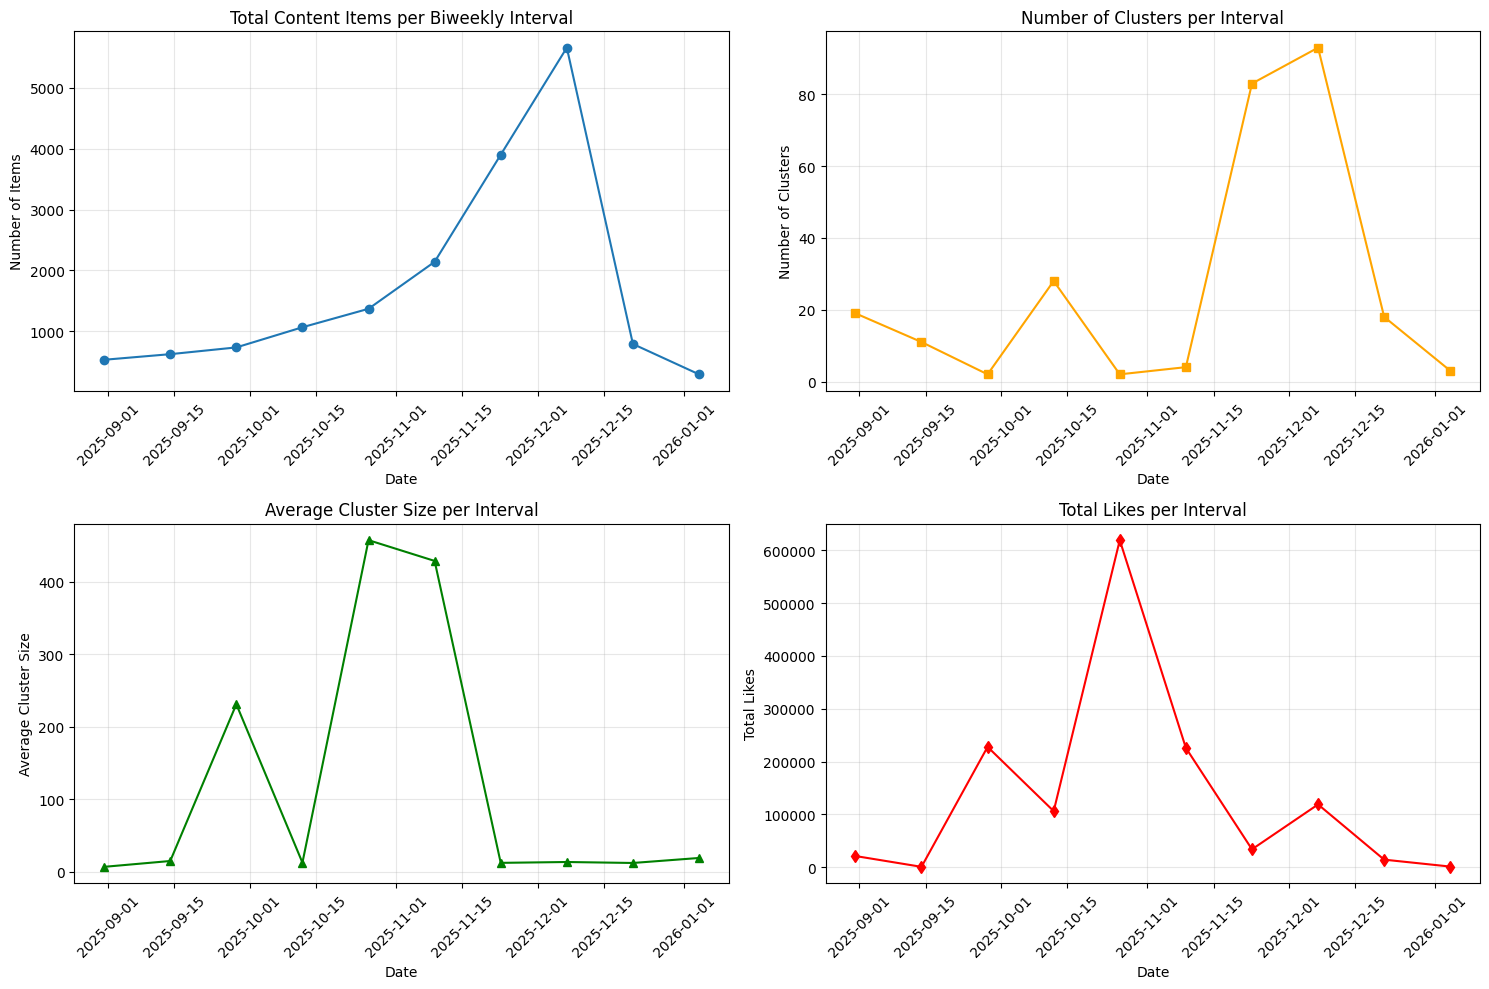

In [19]:
# Plot trends over time
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Total items per interval
axes[0, 0].plot(summary_df['start_date'], summary_df['total_items'], marker='o')
axes[0, 0].set_title('Total Content Items per Biweekly Interval')
axes[0, 0].set_xlabel('Date')
axes[0, 0].set_ylabel('Number of Items')
axes[0, 0].tick_params(axis='x', rotation=45)
axes[0, 0].grid(True, alpha=0.3)

# 2. Number of clusters per interval
axes[0, 1].plot(summary_df['start_date'], summary_df['n_clusters'], marker='s', color='orange')
axes[0, 1].set_title('Number of Clusters per Interval')
axes[0, 1].set_xlabel('Date')
axes[0, 1].set_ylabel('Number of Clusters')
axes[0, 1].tick_params(axis='x', rotation=45)
axes[0, 1].grid(True, alpha=0.3)

# 3. Average cluster size
axes[1, 0].plot(summary_df['start_date'], summary_df['avg_cluster_size'], marker='^', color='green')
axes[1, 0].set_title('Average Cluster Size per Interval')
axes[1, 0].set_xlabel('Date')
axes[1, 0].set_ylabel('Average Cluster Size')
axes[1, 0].tick_params(axis='x', rotation=45)
axes[1, 0].grid(True, alpha=0.3)

# 4. Total likes per interval
axes[1, 1].plot(summary_df['start_date'], summary_df['total_likes'], marker='d', color='red')
axes[1, 1].set_title('Total Likes per Interval')
axes[1, 1].set_xlabel('Date')
axes[1, 1].set_ylabel('Total Likes')
axes[1, 1].tick_params(axis='x', rotation=45)
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Export Results

In [20]:
# Save detailed results to CSV
all_clustered_data = []
for interval_idx, result in interval_results.items():
    df_interval = result['df']
    if 'cluster' in df_interval.columns:
        all_clustered_data.append(df_interval)

if all_clustered_data:
    final_df = pd.concat(all_clustered_data, ignore_index=True)
    final_df.to_csv('hdbscan_clustering_results.csv', index=False)
    print(f"Saved {len(final_df)} clustered items to hdbscan_clustering_results.csv")

# Save summary
summary_df.to_csv('hdbscan_trend_summary.csv', index=False)
print(f"Saved trend summary to hdbscan_trend_summary.csv")

Saved 17124 clustered items to hdbscan_clustering_results.csv
Saved trend summary to hdbscan_trend_summary.csv
